In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [6]:
td_idx=all_bursts['group']=='TD'
asd_idx=all_bursts['group']=='ASD'
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'
hemi_idx = all_bursts['cluster']=='contra'

In [7]:
waveform_times=all_bursts['waveform_times']

In [8]:
subject_ids=np.unique(all_bursts['subject_id'])
groups={}
for subject_id in subject_ids:
    group=all_bursts['group'][all_bursts['subject_id']==subject_id][0].strip()
    groups[subject_id]=group
n_td=len(np.unique(all_bursts['subject_id'][td_idx]))
n_asd=len(np.unique(all_bursts['subject_id'][asd_idx]))
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


min=0.887531412495456, max=0.9995637811951761


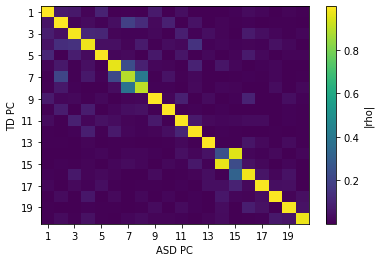

In [9]:
td_pca = PCA(n_components=20)
td_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & td_idx,:])
td_pca=td_pca.fit(td_burst_std)

asd_pca = PCA(n_components=20)
asd_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & asd_idx,:])
asd_pca=asd_pca.fit(asd_burst_std)

def spearman_correlation_matrix(pca1, pca2):
    eigenvectors1 = pca1.components_.T
    eigenvectors2 = pca2.components_.T
    n_components = eigenvectors1.shape[1]
    
    corr_matrix = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            corr, _ = spearmanr(eigenvectors1[:, i], eigenvectors2[:, j])
            corr_matrix[i, j] = abs(corr)  # Absolute value of the Spearman correlation
    return corr_matrix

pca_corr_matrix = spearman_correlation_matrix(td_pca, asd_pca)
max_corrs=[]
for i in range(pca_corr_matrix.shape[0]):
    max_corrs.append(np.max(pca_corr_matrix[i,:]))
print(f'min={np.min(max_corrs)}, max={np.max(max_corrs)}')

plt.figure()
ax=plt.subplot(1,1,1)
im=ax.imshow(pca_corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, label="|rho|")
ax.set_xlabel('ASD PC')
ax.set_ylabel('TD PC')
ax.set_xticks(np.arange(0,20,2))
ax.set_xticklabels(np.arange(0,20,2)+1)
ax.set_yticks(np.arange(0,20,2))
_=ax.set_yticklabels(np.arange(0,20,2)+1)

In [10]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
    waveforms_scaled = RobustScaler().fit_transform(waveforms)

    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


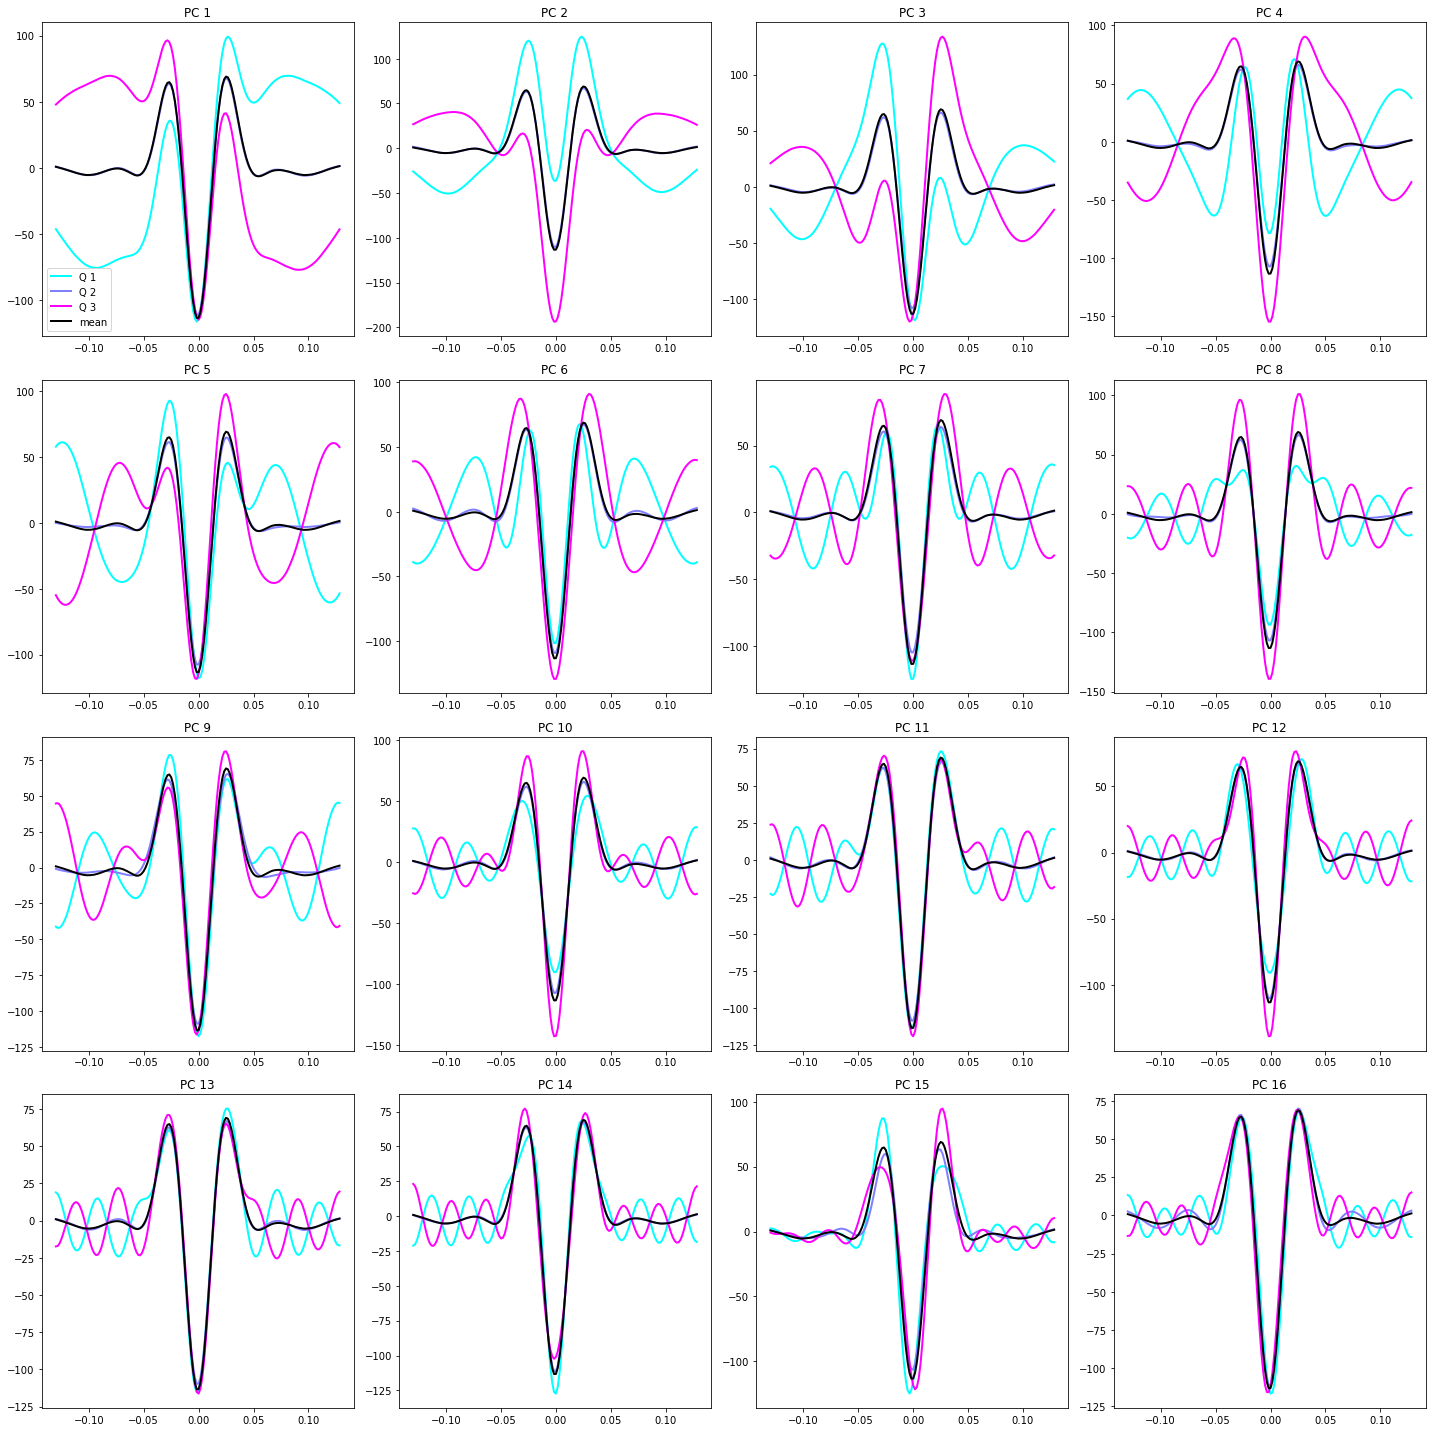

In [11]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={
    epoch_type: {
        condition: [] for condition in condition_names
    } for epoch_type in epoch_types
}
for subject_id in subject_ids:
    for epoch_type in epoch_types:
        for condition in condition_names:
            b_idx=(all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type) & (all_bursts['condition']==condition)
            pc_score_ts=[]
            for t_idx in range(len(stim_time_bins)-1):
                st=stim_time_bins[t_idx]
                en=stim_time_bins[t_idx+1]
                bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
                ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
                pc_score_ts.append(ms)
            pc_score_ts=np.array(pc_score_ts)
            pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
            subject_score_ts[epoch_type][condition].append(pc_score_ts)

for epoch_type in epoch_types:
    for condition in condition_names:
        subject_score_ts[epoch_type][condition]=np.array(subject_score_ts[epoch_type][condition])

PC4 SHORT p=0.003999600039996
PC4 LONG p=9.999000099990002e-05


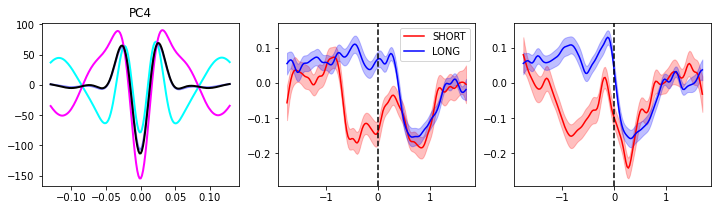

PC6 SHORT p=0.0226977302269773
PC6 LONG p=0.00019998000199980003


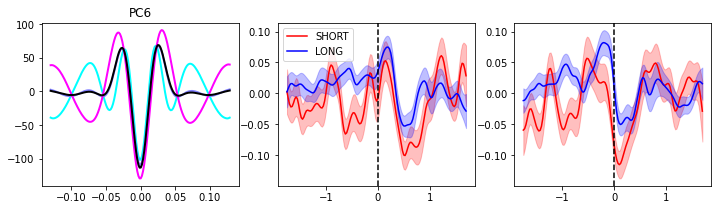

PC7 SHORT p=9.999000099990002e-05
PC7 LONG p=0.0006999300069993001


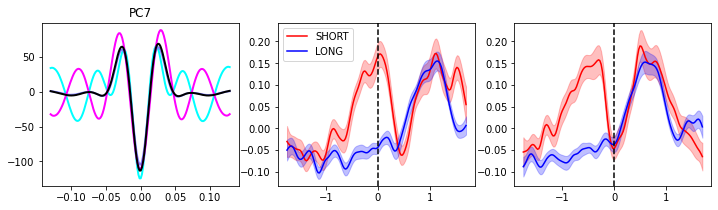

PC8 SHORT p=9.999000099990002e-05
PC8 LONG p=9.999000099990002e-05


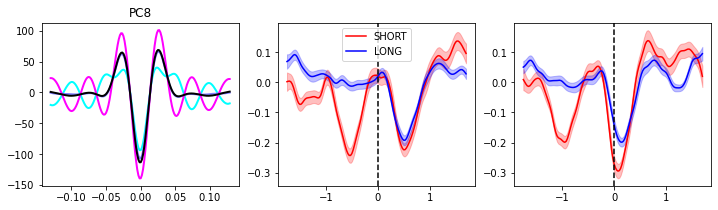

PC10 SHORT p=9.999000099990002e-05
PC10 LONG p=9.999000099990002e-05


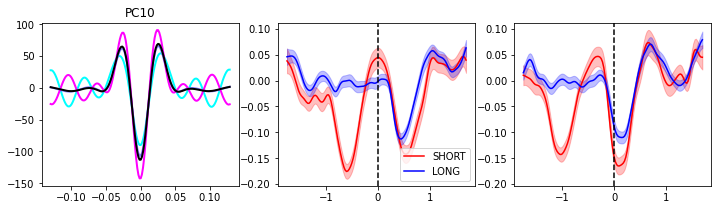

PC12 SHORT p=0.00019998000199980003
PC12 LONG p=9.999000099990002e-05


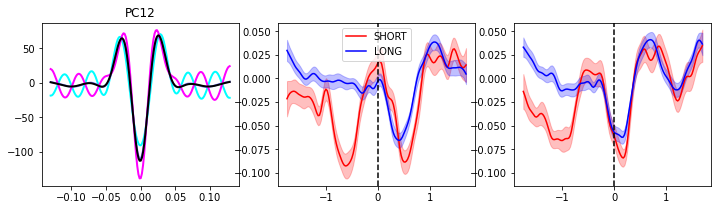

PC16 SHORT p=0.0011998800119988001
PC16 LONG p=0.35566443355664434


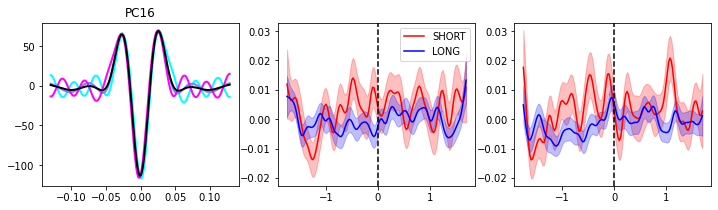

In [14]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -1.5) & (stim_time_bins[:-1] < -1)
resp_mask = (resp_time_bins[:-1] > -.25) & (resp_time_bins[:-1] < .5)

task_pcs=[]

for pc in shuffling_results:
    m_stim_short = np.nanmean(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]
    se_stim_short = np.nanstd(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['SHORT'].shape[0])
    m_resp_short = np.nanmean(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]
    se_resp_short = np.nanstd(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['SHORT'].shape[0])
    
    m_stim_long = np.nanmean(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]
    se_stim_long = np.nanstd(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['LONG'].shape[0])
    m_resp_long = np.nanmean(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]
    se_resp_long = np.nanstd(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['LONG'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data_short = subject_score_ts['STIM']['SHORT'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_short = subject_score_ts['RESP']['SHORT'][:, :, pc]  # shape: n_subj × n_time_resp
    stim_data_long = subject_score_ts['STIM']['LONG'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_long = subject_score_ts['RESP']['LONG'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline_short = np.nanvar(stim_data_short[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_short = np.nanvar(resp_data_short[:, resp_mask], axis=1, ddof=1)
    var_baseline_long = np.nanvar(stim_data_long[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_long = np.nanvar(resp_data_long[:, resp_mask], axis=1, ddof=1)

    diff_short = var_resp_short - var_baseline_short              # ?_i
    diff_long = var_resp_long - var_baseline_long              # ?_i
    obs_stat_short = np.mean(diff_short)                    # observed mean difference across subjects
    obs_stat_long = np.mean(diff_long)                    # observed mean difference across subjects

    # Sign-flip permutation for paired test
    null_stats_short = np.zeros(n_perm)
    null_stats_long = np.zeros(n_perm)
    for p in range(n_perm):
        signs_short = np.random.choice([1, -1], size=diff_short.shape[0])
        signs_long = np.random.choice([1, -1], size=diff_long.shape[0])
        null_stats_short[p] = np.mean(diff_short * signs_short)
        null_stats_long[p] = np.mean(diff_long * signs_long)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val_short = (np.sum(null_stats_short >= obs_stat_short) + 1) / (n_perm + 1)
    p_val_long = (np.sum(null_stats_long >= obs_stat_long) + 1) / (n_perm + 1)
    
    if p_val_short*len(shuffling_results)<0.05 or p_val_long*len(shuffling_results)<0.05:
        print(f'PC{pc+1} SHORT p={p_val_short}')
        print(f'PC{pc+1} LONG p={p_val_long}')
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim_short, color='r', label='SHORT')
        ax1.fill_between(stim_time_bins[:-1], m_stim_short-se_stim_short, m_stim_short+se_stim_short, color='r', alpha=0.25)
        ax1.plot(stim_time_bins[:-1], m_stim_long, color='b', label='LONG')
        ax1.fill_between(stim_time_bins[:-1], m_stim_long-se_stim_long, m_stim_long+se_stim_long, color='b', alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        ax1.legend()
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp_short, color='r')
        ax2.fill_between(resp_time_bins[:-1], m_resp_short-se_resp_short, m_resp_short+se_resp_short, color='r', alpha=0.25)
        ax2.plot(resp_time_bins[:-1], m_resp_long, color='b')
        ax2.fill_between(resp_time_bins[:-1], m_resp_long-se_resp_long, m_resp_long+se_resp_long, color='b', alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

stat_fun(H1): min=-0.819810 max=6.252002
Running initial clustering …
Using 1251 thresholds from 0.00 to 6.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.738521 max=3.205405
Running initial clustering …
Using 748 thresholds from 0.00 to 3.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.640416 max=4.645637
Running initial clustering …
Using 930 thresholds from 0.00 to 4.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.020753 max=7.227097
Running initial clustering …
Using 1446 thresholds from 0.00 to 7.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.923140 max=4.004881
Running initial clustering …
Using 1385 thresholds from 0.00 to 6.92 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

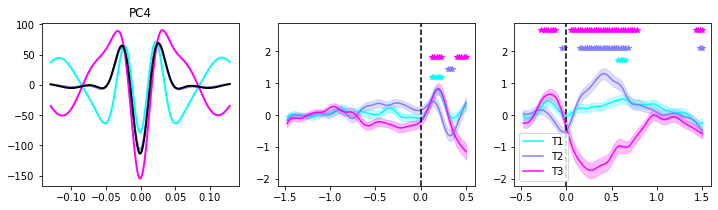

stat_fun(H1): min=-3.173224 max=2.200569
Running initial clustering …
Using 635 thresholds from 0.00 to 3.17 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.373306 max=3.796224
Running initial clustering …
Using 760 thresholds from 0.00 to 3.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.475274 max=6.097377
Running initial clustering …
Using 1220 thresholds from 0.00 to 6.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.892338 max=4.298154
Running initial clustering …
Using 860 thresholds from 0.00 to 4.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.839415 max=3.767979
Running initial clustering …
Using 768 thresholds from 0.00 to 3.83 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

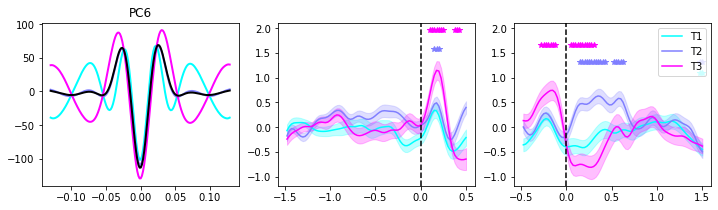

stat_fun(H1): min=-6.022463 max=2.446749
Running initial clustering …
Using 1205 thresholds from 0.00 to 6.02 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.965946 max=5.183843
Running initial clustering …
Using 1037 thresholds from 0.00 to 5.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.121058 max=7.287300
Running initial clustering …
Using 1458 thresholds from 0.00 to 7.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.438055 max=4.148544
Running initial clustering …
Using 888 thresholds from 0.00 to 4.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.706976 max=7.143761
Running initial clustering …
Using 1429 thresholds from 0.00 to 7.14 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

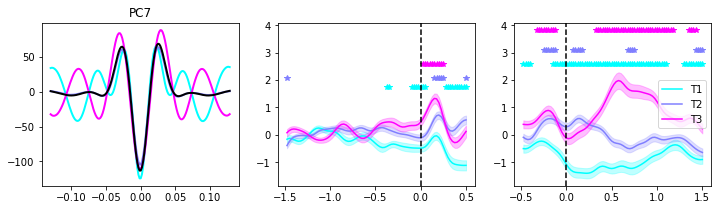

stat_fun(H1): min=-2.434568 max=7.058625
Running initial clustering …
Using 1412 thresholds from 0.00 to 7.05 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.267000 max=5.152086
Running initial clustering …
Using 1031 thresholds from 0.00 to 5.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-9.936177 max=4.160260
Running initial clustering …
Using 1988 thresholds from 0.00 to 9.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.692385 max=4.768513
Running initial clustering …
Using 954 thresholds from 0.00 to 4.76 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-10.293884 max=2.586834
Running initial clustering …
Using 2059 thresholds from 0.00 to 10.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

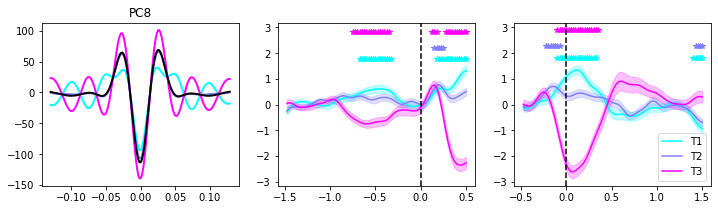

stat_fun(H1): min=-3.275963 max=3.564669
Running initial clustering …
Using 713 thresholds from 0.00 to 3.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.420279 max=5.308244
Running initial clustering …
Using 1062 thresholds from 0.00 to 5.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.566878 max=4.750891
Running initial clustering …
Using 1514 thresholds from 0.00 to 7.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.452889 max=3.909361
Running initial clustering …
Using 1091 thresholds from 0.00 to 5.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.704200 max=4.394586
Running initial clustering …
Using 1741 thresholds from 0.00 to 8.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

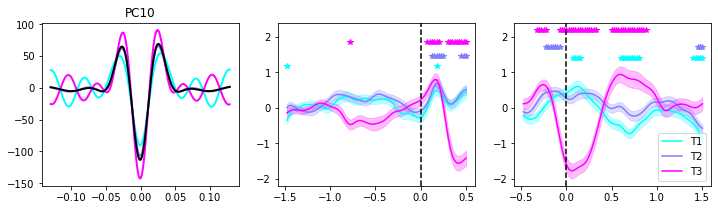

stat_fun(H1): min=-2.687381 max=7.202927
Running initial clustering …
Using 1441 thresholds from 0.00 to 7.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.001762 max=4.889435
Running initial clustering …
Using 978 thresholds from 0.00 to 4.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.874945 max=2.903857
Running initial clustering …
Using 1575 thresholds from 0.00 to 7.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.668580 max=3.392378
Running initial clustering …
Using 1134 thresholds from 0.00 to 5.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.359783 max=3.077472
Running initial clustering …
Using 1472 thresholds from 0.00 to 7.36 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

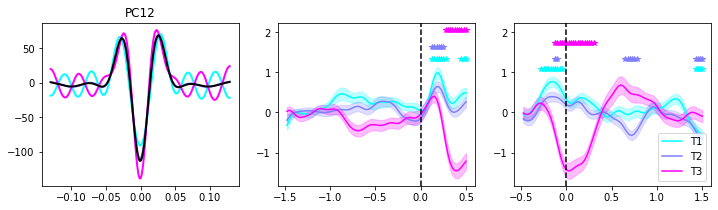

stat_fun(H1): min=-5.006087 max=3.827628
Running initial clustering …
Using 1002 thresholds from 0.00 to 5.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.384272 max=7.566828
Running initial clustering …
Using 1514 thresholds from 0.00 to 7.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.583742 max=4.567035
Running initial clustering …
Using 914 thresholds from 0.00 to 4.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.927802 max=4.935261
Running initial clustering …
Using 988 thresholds from 0.00 to 4.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.580652 max=2.909142
Running initial clustering …
Using 717 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

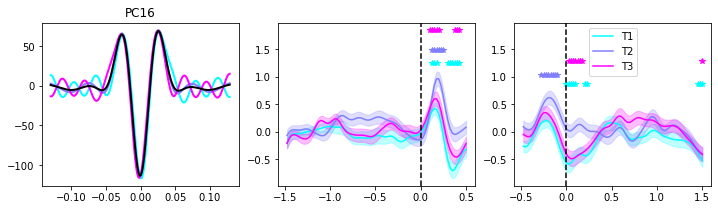

In [15]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: [] for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            stim_trials = np.unique(all_bursts['trial'][stim_b_idx])
            resp_trials = np.unique(all_bursts['trial'][resp_b_idx])

            stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            stim_unsmoothed_rate = (stim_unsmoothed_rate / bin_width) / len(stim_trials)
            resp_unsmoothed_rate = (resp_unsmoothed_rate / bin_width) / len(resp_trials)

            stim_smoothed_rate = gaussian_filter1d(stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_smoothed_rate = gaussian_filter1d(resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-1.5) & (stim_time_bins < -1))[0]
            base_rate = np.mean(stim_smoothed_rate[base_idx])
            stim_smoothed_rate = (stim_smoothed_rate - base_rate)[stim_plt_idx]
            resp_smoothed_rate = (resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM'].append(stim_smoothed_rate)
            q_rates_smoothed[q]['RESP'].append(resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
        
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    # RESP
    ax2 = plt.subplot(1,3,3)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax2.legend()
    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-1.985388 max=2.330677
Running initial clustering …
Using 467 thresholds from 0.00 to 2.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.744590 max=1.524217
Running initial clustering …
Using 549 thresholds from 0.00 to 2.74 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.323616 max=1.759886
Running initial clustering …
Using 1065 thresholds from 0.00 to 5.32 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.644161 max=4.101262
Running initial clustering …
Using 821 thresholds from 0.00 to 4.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.032215 max=3.146637
Running initial clustering …
Using 630 thresholds from 0.00 to 3.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

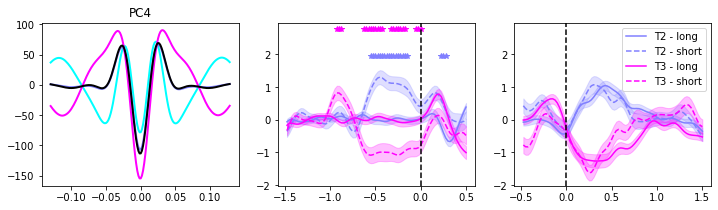

stat_fun(H1): min=-2.653495 max=1.386822
Running initial clustering …
Using 531 thresholds from 0.00 to 2.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.939831 max=0.932837
Running initial clustering …
Using 588 thresholds from 0.00 to 2.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.810569 max=3.546944
Running initial clustering …
Using 710 thresholds from 0.00 to 3.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.903530 max=2.548024
Running initial clustering …
Using 581 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.589738 max=2.539164
Running initial clustering …
Using 518 thresholds from 0.00 to 2.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

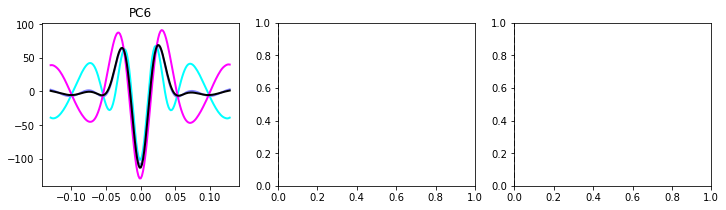

stat_fun(H1): min=-2.255556 max=3.677603
Running initial clustering …
Using 736 thresholds from 0.00 to 3.68 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.121090 max=1.970821
Running initial clustering …
Using 625 thresholds from 0.00 to 3.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.501737 max=1.261922
Running initial clustering …
Using 501 thresholds from 0.00 to 2.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.447604 max=1.499844
Running initial clustering …
Using 690 thresholds from 0.00 to 3.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.482628 max=1.695466
Running initial clustering …
Using 697 thresholds from 0.00 to 3.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

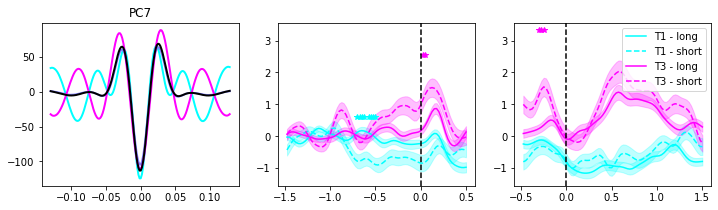

stat_fun(H1): min=-1.712376 max=3.067469
Running initial clustering …
Using 614 thresholds from 0.00 to 3.06 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.967303 max=4.015464
Running initial clustering …
Using 804 thresholds from 0.00 to 4.01 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.976349 max=3.012543
Running initial clustering …
Using 603 thresholds from 0.00 to 3.01 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.562911 max=4.673629
Running initial clustering …
Using 935 thresholds from 0.00 to 4.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.671960 max=0.283407
Running initial clustering …
Using 1335 thresholds from 0.00 to 6.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

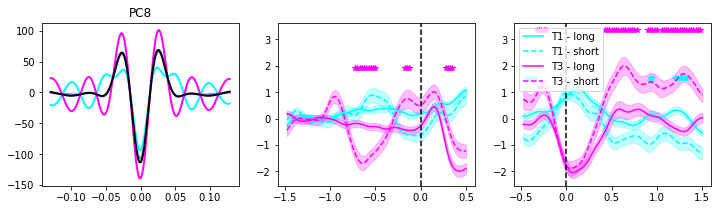

stat_fun(H1): min=-3.233295 max=2.561782
Running initial clustering …
Using 647 thresholds from 0.00 to 3.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.260491 max=1.947906
Running initial clustering …
Using 390 thresholds from 0.00 to 1.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.861778 max=1.549516
Running initial clustering …
Using 373 thresholds from 0.00 to 1.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.590445 max=4.995947
Running initial clustering …
Using 1000 thresholds from 0.00 to 5.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.002743 max=-0.141661
Running initial clustering …
Using 801 thresholds from 0.00 to 4.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

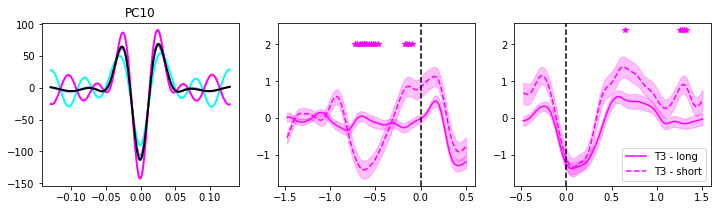

stat_fun(H1): min=-3.577788 max=1.381652
Running initial clustering …
Using 716 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.377799 max=1.125234
Running initial clustering …
Using 476 thresholds from 0.00 to 2.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.137682 max=2.343940
Running initial clustering …
Using 628 thresholds from 0.00 to 3.14 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.253333 max=4.468628
Running initial clustering …
Using 894 thresholds from 0.00 to 4.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.690776 max=0.901410
Running initial clustering …
Using 539 thresholds from 0.00 to 2.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

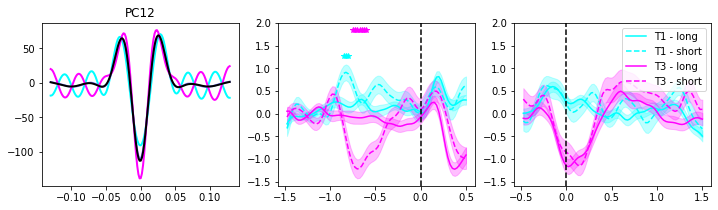

stat_fun(H1): min=-1.731506 max=3.011537
Running initial clustering …
Using 603 thresholds from 0.00 to 3.01 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.194198 max=1.711355
Running initial clustering …
Using 639 thresholds from 0.00 to 3.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.344853 max=3.264162
Running initial clustering …
Using 669 thresholds from 0.00 to 3.34 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.492067 max=1.934334
Running initial clustering …
Using 499 thresholds from 0.00 to 2.49 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.755132 max=1.240185
Running initial clustering …
Using 552 thresholds from 0.00 to 2.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

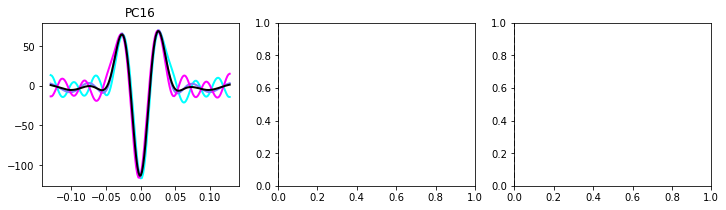

In [16]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins > -1.5) & (stim_time_bins < -1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(short_stim_smoothed_rate[base_idx])
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.483416 max=2.103023
Running initial clustering …
Using 497 thresholds from 0.00 to 2.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.247482 max=0.121764
Running initial clustering …
Using 450 thresholds from 0.00 to 2.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.270450 max=1.716888
Running initial clustering …
Using 1055 thresholds from 0.00 to 5.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.286993 max=4.491370
Running initial clustering …
Using 899 thresholds from 0.00 to 4.49 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.047565 max=3.045025
Running initial clustering …
Using 610 thresholds from 0.00 to 3.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

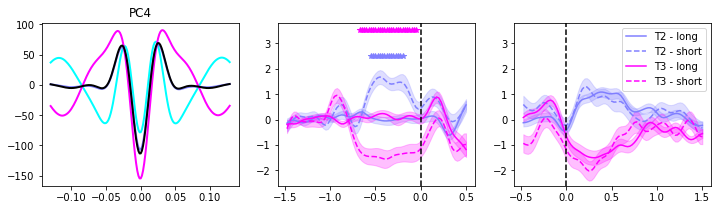

stat_fun(H1): min=-2.834916 max=1.513570
Running initial clustering …
Using 567 thresholds from 0.00 to 2.83 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.389524 max=0.810607
Running initial clustering …
Using 678 thresholds from 0.00 to 3.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.606674 max=3.862803
Running initial clustering …
Using 773 thresholds from 0.00 to 3.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.840843 max=3.338510
Running initial clustering …
Using 668 thresholds from 0.00 to 3.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.004731 max=1.990045
Running initial clustering …
Using 401 thresholds from 0.00 to 2.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

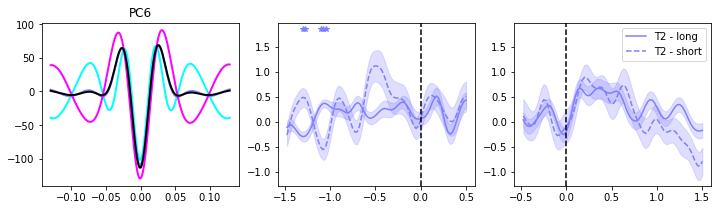

stat_fun(H1): min=-2.361693 max=3.389208
Running initial clustering …
Using 678 thresholds from 0.00 to 3.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.801880 max=2.256260
Running initial clustering …
Using 561 thresholds from 0.00 to 2.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.646448 max=1.001763
Running initial clustering …
Using 730 thresholds from 0.00 to 3.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.799933 max=2.290401
Running initial clustering …
Using 560 thresholds from 0.00 to 2.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.755753 max=1.798749
Running initial clustering …
Using 552 thresholds from 0.00 to 2.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

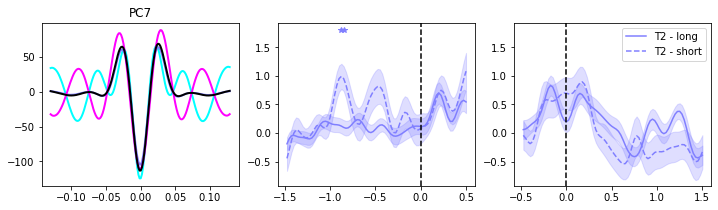

stat_fun(H1): min=-2.156108 max=1.997911
Running initial clustering …
Using 432 thresholds from 0.00 to 2.16 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.326362 max=3.188265
Running initial clustering …
Using 638 thresholds from 0.00 to 3.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.613522 max=2.160244
Running initial clustering …
Using 523 thresholds from 0.00 to 2.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.369233 max=5.079584
Running initial clustering …
Using 1016 thresholds from 0.00 to 5.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.196972 max=-0.413824
Running initial clustering …
Using 1040 thresholds from 0.00 to 5.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

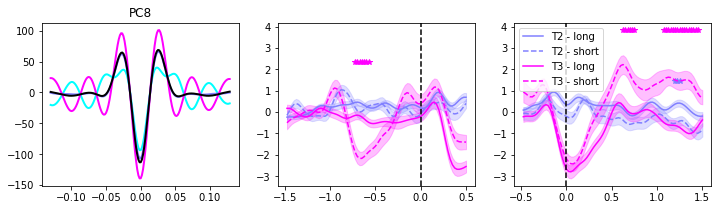

stat_fun(H1): min=-2.748138 max=2.379332
Running initial clustering …
Using 550 thresholds from 0.00 to 2.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.613205 max=1.864133
Running initial clustering …
Using 373 thresholds from 0.00 to 1.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.998883 max=1.973960
Running initial clustering …
Using 400 thresholds from 0.00 to 2.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.836163 max=4.576472
Running initial clustering …
Using 916 thresholds from 0.00 to 4.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.923819 max=1.096725
Running initial clustering …
Using 585 thresholds from 0.00 to 2.92 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

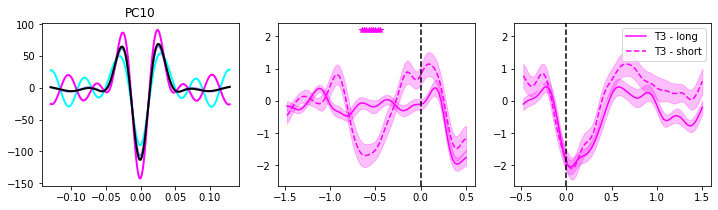

stat_fun(H1): min=-4.440459 max=1.466493
Running initial clustering …
Using 889 thresholds from 0.00 to 4.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.994591 max=1.266209
Running initial clustering …
Using 399 thresholds from 0.00 to 1.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.609067 max=2.052503
Running initial clustering …
Using 722 thresholds from 0.00 to 3.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.351685 max=4.757723
Running initial clustering …
Using 952 thresholds from 0.00 to 4.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.782712 max=0.611849
Running initial clustering …
Using 557 thresholds from 0.00 to 2.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

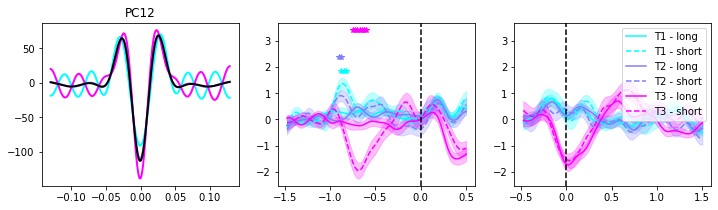

stat_fun(H1): min=-1.579288 max=3.215362
Running initial clustering …
Using 644 thresholds from 0.00 to 3.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.472421 max=1.286546
Running initial clustering …
Using 695 thresholds from 0.00 to 3.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.126416 max=3.220323
Running initial clustering …
Using 1026 thresholds from 0.00 to 5.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.006875 max=2.281890
Running initial clustering …
Using 457 thresholds from 0.00 to 2.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.154821 max=1.584778
Running initial clustering …
Using 431 thresholds from 0.00 to 2.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

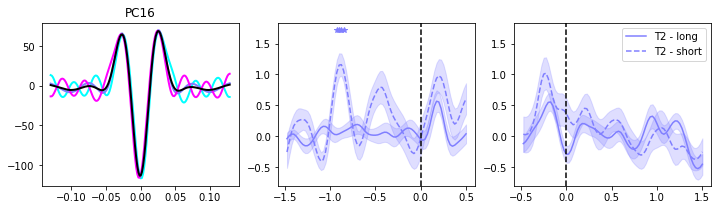

In [17]:
## TD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='TD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins > -1.5) & (stim_time_bins < -1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                base_rate = np.mean(short_stim_smoothed_rate[base_idx])
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-1.868080 max=1.913238
Running initial clustering …
Using 383 thresholds from 0.00 to 1.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.062122 max=2.771426
Running initial clustering …
Using 555 thresholds from 0.00 to 2.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.707260 max=1.788496
Running initial clustering …
Using 542 thresholds from 0.00 to 2.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.932251 max=1.924094
Running initial clustering …
Using 587 thresholds from 0.00 to 2.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.574868 max=1.496658
Running initial clustering …
Using 515 thresholds from 0.00 to 2.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

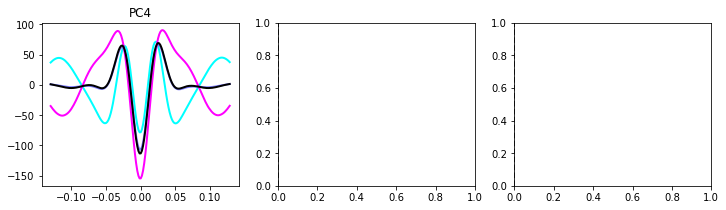

stat_fun(H1): min=-1.447607 max=1.783650
Running initial clustering …
Using 357 thresholds from 0.00 to 1.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.276959 max=0.635484
Running initial clustering …
Using 456 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.107645 max=1.450956
Running initial clustering …
Using 422 thresholds from 0.00 to 2.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.913526 max=1.868557
Running initial clustering …
Using 383 thresholds from 0.00 to 1.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.972513 max=1.698588
Running initial clustering …
Using 395 thresholds from 0.00 to 1.97 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

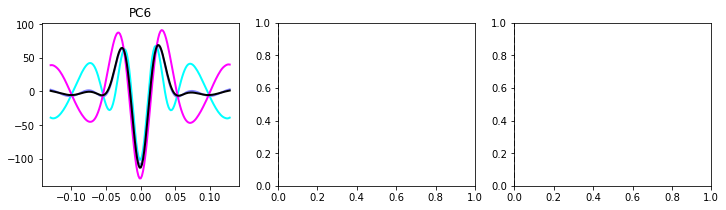

stat_fun(H1): min=-2.366419 max=2.638121
Running initial clustering …
Using 528 thresholds from 0.00 to 2.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.776539 max=0.867676
Running initial clustering …
Using 556 thresholds from 0.00 to 2.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.001015 max=1.529861
Running initial clustering …
Using 601 thresholds from 0.00 to 3.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.476820 max=0.519285
Running initial clustering …
Using 496 thresholds from 0.00 to 2.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.315477 max=0.729131
Running initial clustering …
Using 664 thresholds from 0.00 to 3.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

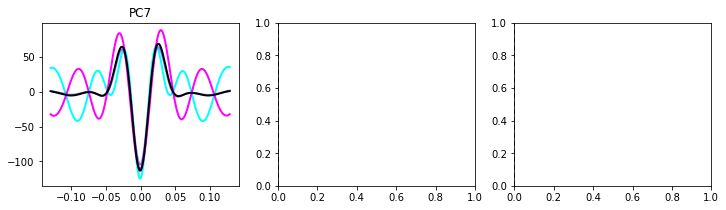

stat_fun(H1): min=-1.761570 max=2.931891
Running initial clustering …
Using 587 thresholds from 0.00 to 2.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.009025 max=3.201843
Running initial clustering …
Using 641 thresholds from 0.00 to 3.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.234562 max=2.264419
Running initial clustering …
Using 647 thresholds from 0.00 to 3.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.278995 max=2.634320
Running initial clustering …
Using 527 thresholds from 0.00 to 2.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.649743 max=1.393136
Running initial clustering …
Using 930 thresholds from 0.00 to 4.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

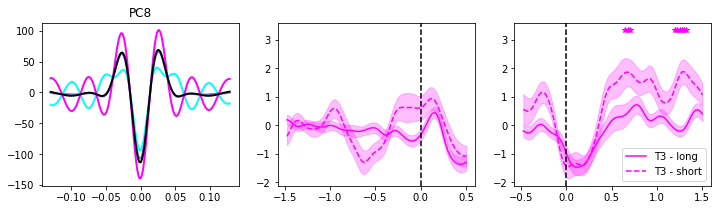

stat_fun(H1): min=-3.617668 max=2.151954
Running initial clustering …
Using 724 thresholds from 0.00 to 3.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.004010 max=2.571192
Running initial clustering …
Using 515 thresholds from 0.00 to 2.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.428991 max=0.994109
Running initial clustering …
Using 286 thresholds from 0.00 to 1.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.301802 max=3.514525
Running initial clustering …
Using 703 thresholds from 0.00 to 3.51 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.567569 max=0.227507
Running initial clustering …
Using 714 thresholds from 0.00 to 3.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

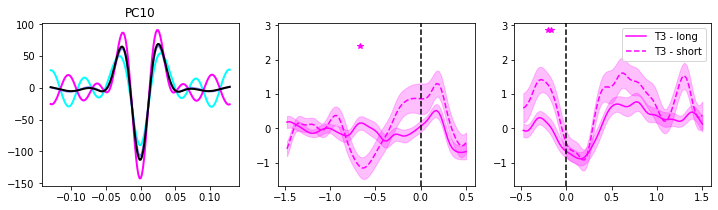

stat_fun(H1): min=-2.398100 max=1.117399
Running initial clustering …
Using 480 thresholds from 0.00 to 2.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.183566 max=1.296244
Running initial clustering …
Using 637 thresholds from 0.00 to 3.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.174701 max=2.213213
Running initial clustering …
Using 443 thresholds from 0.00 to 2.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.346690 max=1.879165
Running initial clustering …
Using 470 thresholds from 0.00 to 2.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.669384 max=1.812887
Running initial clustering …
Using 363 thresholds from 0.00 to 1.81 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

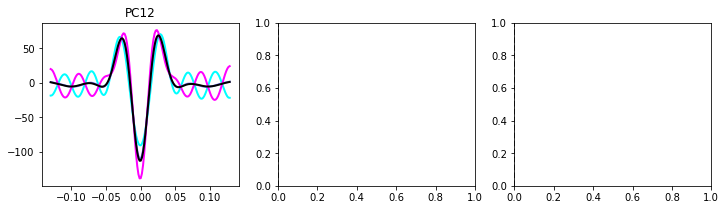

stat_fun(H1): min=-1.701968 max=2.700879
Running initial clustering …
Using 541 thresholds from 0.00 to 2.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.158538 max=2.043510
Running initial clustering …
Using 432 thresholds from 0.00 to 2.16 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.350636 max=2.323257
Running initial clustering …
Using 471 thresholds from 0.00 to 2.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.711112 max=1.565562
Running initial clustering …
Using 543 thresholds from 0.00 to 2.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.611116 max=0.487750
Running initial clustering …
Using 923 thresholds from 0.00 to 4.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

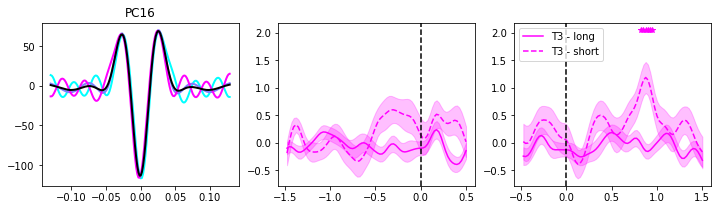

In [18]:
## ASD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='ASD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins > -1.5) & (stim_time_bins < -1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                base_rate = np.mean(short_stim_smoothed_rate[base_idx])
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=0.000345 max=4.532643
Running initial clustering …
Using 907 thresholds from 0.00 to 4.53 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000010 max=7.902615
Running initial clustering …
Using 1581 thresholds from 0.00 to 7.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000010 max=2.272183
Running initial clustering …
Using 455 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000620 max=10.494605
Running initial clustering …
Using 2099 thresholds from 0.00 to 10.49 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.116212 max=10.695791
Running initial clustering …
Using 2140 thresholds from 0.00 to 10.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

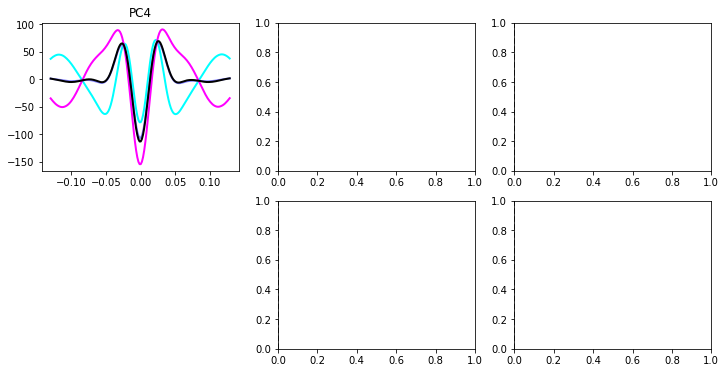

stat_fun(H1): min=0.000007 max=4.890286
Running initial clustering …
Using 979 thresholds from 0.00 to 4.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000971 max=9.688408
Running initial clustering …
Using 1938 thresholds from 0.00 to 9.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000104 max=6.569651
Running initial clustering …
Using 1314 thresholds from 0.00 to 6.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000147 max=3.286129
Running initial clustering …
Using 658 thresholds from 0.00 to 3.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000064 max=2.914624
Running initial clustering …
Using 583 thresholds from 0.00 to 2.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

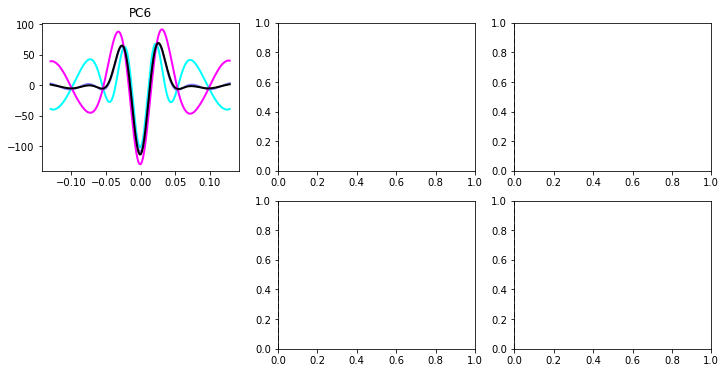

stat_fun(H1): min=0.000032 max=2.551586
Running initial clustering …
Using 511 thresholds from 0.00 to 2.55 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001793 max=14.156076
Running initial clustering …
Using 2832 thresholds from 0.00 to 14.16 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001696 max=2.017872
Running initial clustering …
Using 404 thresholds from 0.00 to 2.02 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000020 max=2.757101
Running initial clustering …
Using 552 thresholds from 0.00 to 2.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000005 max=6.721491
Running initial clustering …
Using 1345 thresholds from 0.00 to 6.72 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

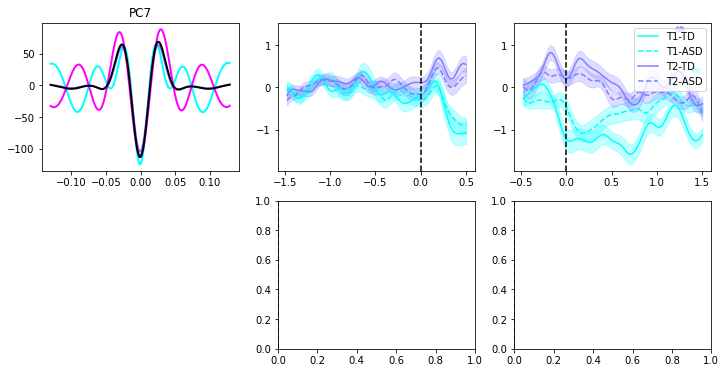

stat_fun(H1): min=0.000134 max=2.509021
Running initial clustering …
Using 502 thresholds from 0.00 to 2.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000254 max=4.876444
Running initial clustering …
Using 976 thresholds from 0.00 to 4.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.008738 max=6.731865
Running initial clustering …
Using 1347 thresholds from 0.00 to 6.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000254 max=3.887916
Running initial clustering …
Using 778 thresholds from 0.00 to 3.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002973 max=3.646082
Running initial clustering …
Using 730 thresholds from 0.00 to 3.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

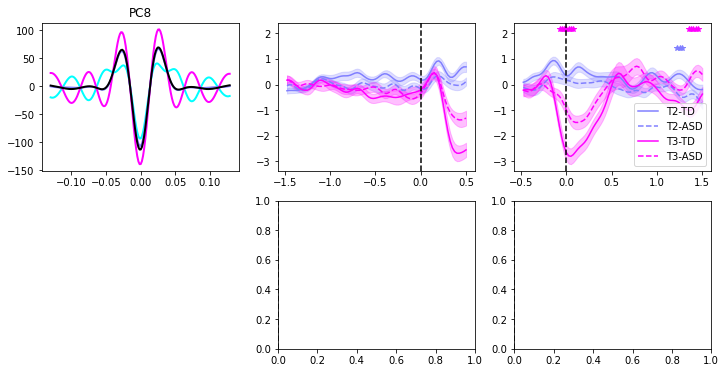

stat_fun(H1): min=0.000001 max=9.608482
Running initial clustering …
Using 1922 thresholds from 0.00 to 9.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.013285 max=11.488938
Running initial clustering …
Using 2298 thresholds from 0.00 to 11.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000045 max=2.384541
Running initial clustering …
Using 477 thresholds from 0.00 to 2.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000322 max=6.374846
Running initial clustering …
Using 1275 thresholds from 0.00 to 6.37 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000065 max=9.191790
Running initial clustering …
Using 1839 thresholds from 0.00 to 9.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

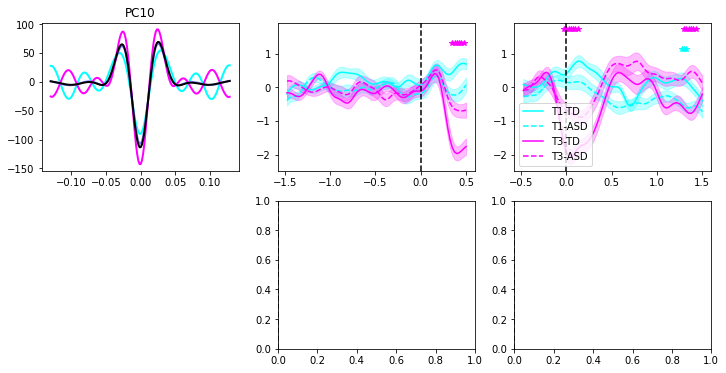

stat_fun(H1): min=0.000299 max=2.912284
Running initial clustering …
Using 583 thresholds from 0.00 to 2.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002135 max=3.284967
Running initial clustering …
Using 657 thresholds from 0.00 to 3.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000334 max=6.577843
Running initial clustering …
Using 1316 thresholds from 0.00 to 6.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000004 max=12.974355
Running initial clustering …
Using 2595 thresholds from 0.00 to 12.97 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000063 max=7.563707
Running initial clustering …
Using 1513 thresholds from 0.00 to 7.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

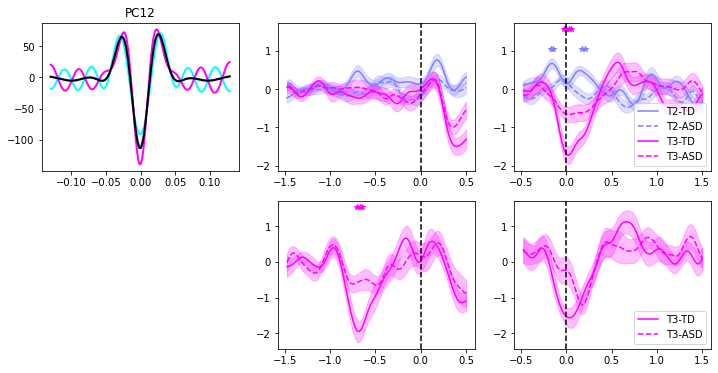

stat_fun(H1): min=0.000821 max=4.563318
Running initial clustering …
Using 913 thresholds from 0.00 to 4.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000540 max=5.020424
Running initial clustering …
Using 1005 thresholds from 0.00 to 5.02 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000092 max=2.151095
Running initial clustering …
Using 431 thresholds from 0.00 to 2.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002467 max=5.587300
Running initial clustering …
Using 1118 thresholds from 0.00 to 5.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000003 max=10.748772
Running initial clustering …
Using 2150 thresholds from 0.00 to 10.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

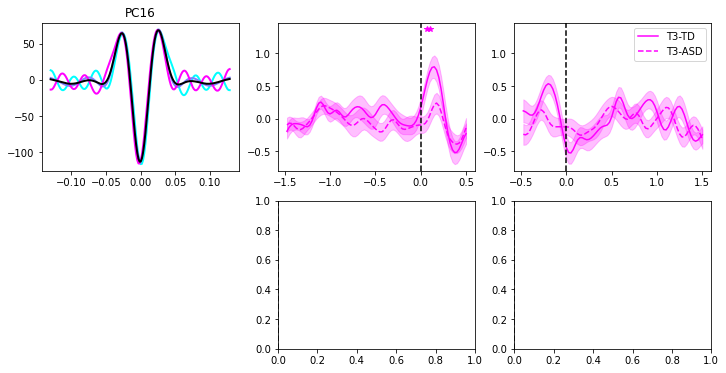

In [19]:
step = 100 / n_q

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        group: {
            q: {
                epoch_type: {
                    condition: [] for condition in condition_names
                } for epoch_type in epoch_types
            } for q in range(n_q)
        } for group in ['ASD','TD']
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins > -1.5) & (stim_time_bins < -1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(short_stim_smoothed_rate[base_idx])
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[subject_group][q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,6))

    ax=plt.subplot(2,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(2,3,2)
    # RESP
    ax2 = plt.subplot(2,3,3)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['LONG']), np.array(q_rates_smoothed['ASD'][q]['STIM']['LONG'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['LONG']), np.array(q_rates_smoothed['ASD'][q]['RESP']['LONG'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    
    ax1 = plt.subplot(2,3,5)
    # RESP
    ax2 = plt.subplot(2,3,6)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )

        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()